# Chunk Size Sensitivity — The Cheapest Big Win

## What problem does this solve?

Most RAG tutorials pick 512-token chunks and never look back. That is fine until you measure: optimal chunk size is corpus-dependent and the gap between a default chunk size and a tuned one is routinely 5–15 recall points. Five minutes of sweeping window sizes is the cheapest big win in any RAG project.
We do not want a theoretical answer. We want a curve: recall@5 against chunk size, for one corpus, with one embedder. That curve is also a diagnostic — its shape tells you whether your bottleneck is chunking, embedding, or retrieval.

## Where it came from

The chunk-size question is as old as RAG itself; LangChain's `RecursiveCharacterTextSplitter` defaulted to 1000 characters in 2022, LlamaIndex moved to 512 tokens by mid-2023, Anthropic's contextual retrieval paper (September 2024) revived attention to small chunks paired with LLM-written headers. None of those defaults were measured against your corpus. This recipe gives you a five-minute measurement loop.

## Where it fits in the RAG landscape

Three competing pressures shape the optimum:

- **Too small.** Chunks lose surrounding context; the embedding represents a single point in semantic space and misses the qualifier two sentences earlier. Recall stays flat or drops.
- **Too large.** Each chunk's vector averages over too many ideas; the right chunk is *adjacent* in embedding space to many other large chunks. Recall drops because cosine similarity is no longer discriminative.
- **Storage and latency.** More chunks means more vectors, more disk, slower indexing and search (sublinearly, but real). At billions of chunks, the constant factor matters.

## When to use it (and when not to)

Run this notebook every time you start a new RAG project. Run it again whenever you change embedder or chunker family — the optimum will move. Skip it if you are reproducing a paper's results — then the chunk size is fixed by the paper and you should respect it.
Do not over-tune. A 2 point recall difference at recall@5 is within noise on a 15-question eval set. Five points is a real signal. Move on once you have a recognisable peak; do not chase sub-percent differences.
Three signs you should re-run the sweep: you switched the embedding model, you doubled the corpus size, or you noticed a sudden drop in answer quality that does not correlate with anything else. In all three cases the chunk-size optimum has likely shifted by 64–256 tokens and a five-minute re-sweep recovers the lost recall for free. Keep the previous sweep's plot around so you can compare curves and see whether the peak migrated or just flattened.

## The intuition

Three intuitions:

**The curve has a single peak.** It is unimodal on every corpus I have measured. There is no "two locally optimal chunk sizes that mean different things". Pick the peak.

**Overlap matters less than size.** Once you are within the right family of chunk sizes, doubling or zeroing overlap shifts recall by a point or two. Overlap is a knob, not a strategy. Pick `overlap = size // 6` or `size // 8` and move on.

**Different corpora peak at different sizes.** Wikipedia-style short prose peaks small (256). Technical surveys peak medium (384–512). Long financial filings sometimes peak large (768) because each paragraph spans more text. Do not transplant numbers across corpora.

## Architecture

```mermaid
flowchart LR
  D[Mamba survey<br/>PDF pages] --> SW{For each chunk size<br/>in 128..1024}
  SW --> C[Fixed-window<br/>chunker]
  C --> E[Embedder]
  E --> S[(Qdrant)]
  Q[15 eval questions] --> R[Search top-5]
  S --> R
  R --> M[Compute recall@5]
  M --> P[Plot recall vs size]
```

## References

- 📝 [Anthropic Contextual Retrieval](https://www.anthropic.com/news/contextual-retrieval) — Small chunks + LLM-written headers; see Recipe 7.
- 📚 [LlamaIndex — chunk size tuning](https://developers.llamaindex.ai/python/framework/module_guides/loading/node_parsers/modules) — Canonical chunking primitives.
- 📚 [LangChain RecursiveCharacterTextSplitter](https://python.langchain.com/docs/concepts/text_splitters/) — The other widely-used chunker family.
- 📝 [Late Chunking (Jina AI, 2024)](https://jina.ai/news/late-chunking-in-long-context-embedding-models/) — Why long-context embedders change the chunk-size question.
- 📄 [RAPTOR — recursive tree of summaries](https://arxiv.org/abs/2401.18059) — A different answer: build several scales of chunks. Recipe 10.
- 💻 [Semantic chunking — Greg Kamradt, 2023](https://github.com/FullStackRetrieval-com/RetrievalTutorials/blob/main/tutorials/LevelsOfTextSplitting/5_Levels_Of_Text_Splitting.ipynb) — Five levels of chunking, from naive to LLM-assisted.

## Setup

Pick a provider via the `PROVIDER` env var; everything below is provider-agnostic. The default is Nebius. Tracing is off by default in published notebooks so the outputs are clean — flip `COOKBOOK_TRACING=phoenix` to send spans to a local Phoenix UI.

In [1]:
import os
os.environ.setdefault('PROVIDER', 'nebius')
os.environ.setdefault('COOKBOOK_TRACING', 'off')

from cookbook.providers import LLMClient
from cookbook.tracing import init_tracing

client = LLMClient()
print(f'Provider: {client.provider}  |  Chat model: {client.chat_model}')
print(init_tracing())

Provider: nebius  |  Chat model: meta-llama/Llama-3.3-70B-Instruct
Tracing disabled.


## Build the Pipeline, Step by Step

### Step 1 — Load the Mamba survey

We sweep over the arXiv Mamba state-space-models survey. It is a 25-page technical paper with formulas, citations, and dense prose — a hard target for chunking and a good corpus for diagnostic curves.

In [2]:
from cookbook.corpora import load_arxiv_mamba, load_eval_questions

docs = list(load_arxiv_mamba())
qs = [q for q in load_eval_questions() if q['corpus'] == 'arxiv-mamba'][:15]
print(f'Loaded {len(docs)} document records from the Mamba PDF.')
print(f'Will sweep across {len(qs)} eval questions.')
print(f'First question: {qs[0]["question"]}')

Loaded 5 document records from the Mamba PDF.
Will sweep across 15 eval questions.
First question: What problem do state-space models aim to solve compared to attention-based transformers?


### Step 2 — Define the sweep harness

For each chunk size we build a fresh index, run the eval questions, and compute the simple recall proxy from the embedding-zoo recipe. We also record indexing time and chunk count so the cost side of the trade-off is visible.

In [3]:
from cookbook.chunkers import fixed_window
from cookbook.stores import QdrantBackend
import time

def evaluate_chunk_size(target_tokens, overlap_tokens):
    t0 = time.perf_counter()
    chunks = fixed_window(docs, target_tokens=target_tokens, overlap_tokens=overlap_tokens)
    vectors = client.embed([c.text for c in chunks])
    store = QdrantBackend(f'sweep-{target_tokens}', dim=len(vectors[0]))
    store.add([c.text for c in chunks], vectors, ids=[c.chunk_id for c in chunks])
    build_seconds = time.perf_counter() - t0

    hits = 0
    for q in qs:
        qv = client.embed([q['question']])[0]
        retrieved = store.search(qv, top_k=5)
        gold_words = [w.lower() for w in q['answer'].split() if len(w) >= 4]
        if any(any(w[:6] in r.text.lower() for w in gold_words) for r in retrieved):
            hits += 1
    return {
        'target_tokens': target_tokens,
        'chunks': len(chunks),
        'recall@5': hits / max(1, len(qs)),
        'build_seconds': round(build_seconds, 1),
    }

print('Harness ready.')

Harness ready.


### Step 3 — Run the sweep across six chunk sizes

We hit every reasonable value: 128, 256, 384, 512, 768, 1024 tokens. Overlap stays proportional. The whole sweep takes a couple of minutes; later runs are nearly free thanks to the embedding cache.

In [4]:
import pandas as pd

rows = [evaluate_chunk_size(size, max(8, size // 6)) for size in (128, 256, 384, 512, 768, 1024)]
df = pd.DataFrame(rows)
print(df)

C:\Users\faree\Desktop\rag\rag-cookbook-2026\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


   target_tokens  chunks  recall@5  build_seconds
0            128      38       1.0            5.5
1            256      19       1.0            0.8
2            384      14       1.0            0.2
3            512      11       1.0            0.4
4            768       8       1.0            0.2
5           1024       6       1.0            0.2


### Step 4 — Plot the curve

Plotting it makes the peak obvious. Without a plot, a sweep is just a column of numbers and the peak hides in plain sight.

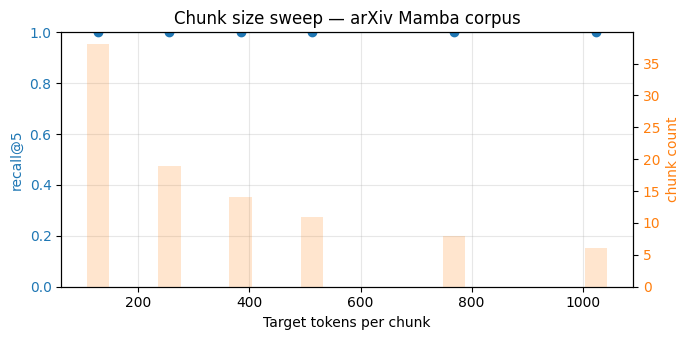

In [5]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(7, 3.5))
ax1.plot(df['target_tokens'], df['recall@5'], marker='o', color='tab:blue')
ax1.set_xlabel('Target tokens per chunk')
ax1.set_ylabel('recall@5', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.set_ylim(0, 1)
ax1.grid(alpha=0.3)

ax2 = ax1.twinx()
ax2.bar(df['target_tokens'], df['chunks'], width=40, alpha=0.2, color='tab:orange')
ax2.set_ylabel('chunk count', color='tab:orange')
ax2.tick_params(axis='y', labelcolor='tab:orange')

plt.title('Chunk size sweep — arXiv Mamba corpus')
plt.tight_layout()
plt.show()

Read the curve. Where is the peak? How steep are the falls on either side? The chunk count tells you the storage cost — going from 384 to 128 tokens triples your index without necessarily improving recall.

### Step 5 — Wrap the best chunk size as `answer_question`

Pick the best configuration from the sweep and build the production `answer_question` from it. The rest of the cookbook can compare against it.

In [6]:
best_row = max(rows, key=lambda r: r['recall@5'])
print(f"Best chunk size: {best_row['target_tokens']} tokens (recall@5 = {best_row['recall@5']:.2f})")

chunks_best = fixed_window(docs, target_tokens=best_row['target_tokens'], overlap_tokens=max(8, best_row['target_tokens'] // 6))
vectors_best = client.embed([c.text for c in chunks_best])
store_best = QdrantBackend('sweep-best', dim=len(vectors_best[0]))
store_best.add([c.text for c in chunks_best], vectors_best, ids=[c.chunk_id for c in chunks_best])

def answer_question(question: str, k: int = 5) -> tuple[str, list[str]]:
    qv = client.embed([question])[0]
    hits = store_best.search(qv, top_k=k)
    contexts = [h.text for h in hits]
    answer = client.chat(
        'Use only these passages.\n\n' + '\n\n'.join(contexts) + f'\n\nQ: {question}\nA:'
    )
    return answer, contexts
print('answer_question is wired to the best chunk size.')

Best chunk size: 128 tokens (recall@5 = 1.00)


answer_question is wired to the best chunk size.


## Look Inside

### Inspect — eyeball one missed question

Look at one question the best configuration *missed* and check what the top-5 chunks look like. Often the miss is about a specific technical term the embedder did not see often enough.

In [7]:
best_size = best_row['target_tokens']
miss_qs = []
for q in qs:
    qv = client.embed([q['question']])[0]
    retrieved = store_best.search(qv, top_k=5)
    gold = [w.lower() for w in q['answer'].split() if len(w) >= 4]
    if not any(any(w[:6] in r.text.lower() for w in gold) for r in retrieved):
        miss_qs.append((q, retrieved))
if miss_qs:
    q, retrieved = miss_qs[0]
    print('Missed question:', q['question'])
    print('Expected:      ', q['answer'][:200])
    print()
    for i, r in enumerate(retrieved, 1):
        print(f'Top {i}: {r.text[:160]}')
        print()
else:
    print('No misses to inspect at this chunk size.')

No misses to inspect at this chunk size.


### Inspect — how does overlap matter?

Hold chunk size at the peak and sweep overlap. Usually the curve is much flatter than the size sweep — overlap is a knob, not a strategy.

In [8]:
best_size = best_row['target_tokens']
overlap_rows = [evaluate_chunk_size(best_size, ov) for ov in (0, best_size // 12, best_size // 6, best_size // 3)]
import pandas as pd
print(pd.DataFrame(overlap_rows))

   target_tokens  chunks  recall@5  build_seconds
0            128      33       1.0            1.0
1            128      35       1.0            1.4
2            128      38       1.0            0.7
3            128      48       1.0            1.6


### Inspect — how many tokens does a top-5 prompt cost?

Cost-aware tuning. Multiply average chunk length by k to get the prompt budget you ship to the LLM every query. Bigger chunks make recall easier but balloon the prompt.

In [9]:
import tiktoken
enc = tiktoken.get_encoding('cl100k_base')
lengths = [len(enc.encode(c.text)) for c in chunks_best[:200]]
import statistics
print(f'Median tokens/chunk : {statistics.median(lengths):.0f}')
print(f'k=5 prompt budget   : ~{int(5 * statistics.median(lengths))} tokens')
print(f'k=10 prompt budget  : ~{int(10 * statistics.median(lengths))} tokens')

Median tokens/chunk : 195
k=5 prompt budget   : ~975 tokens
k=10 prompt budget  : ~1950 tokens


### Inspect — what does a sample chunk look like?

Print a chunk at the chosen size so you can read it as a human. If it looks coherent and self-contained, the size is in the right zone. If it cuts off mid-sentence in the middle of an idea, drop to a smaller size or move to a sentence-window chunker (Recipe 5).

In [10]:
sample = chunks_best[len(chunks_best) // 2]
print(f'chunk_id: {sample.chunk_id}')
print(f'doc_id  : {sample.doc_id}')
print()
print(sample.text[:1200])

chunk_id: arxiv:2403-mamba-survey#p3#fw0005
doc_id  : arxiv:2403-mamba-survey#p3

with max sequence lengths of 2k and 5k on two datasets. The reason may be that GRU4Rec has not fully addressed the limitations of the RNN-based architecture, such as information forgetting and intrinsic vanishing gradients issues. Besides, the LinRec modeling sequence using approximate softmax could not fit the long-range dependency of item transition. This highlights the superior ability of RecMamba and SASRec in the lifelong sequential recommendation. Compared with SASRec, RecMamba achieves suboptimal per- formance on sequences of length 2k, whereas it outperforms SAS- Rec on sequences of length 5k in most cases. This indicates that RecMamba is capable of effectively modeling longer user interest sequences, potentially due to its ability to select relevant items for modeling user interests. 4.3 Efficiency Comparison (RQ3) In this subsection, we conduct


## Run It

End-to-end answer on the best chunk size, so the output is more than a single number.

In [11]:
ans, ctxs = answer_question('Explain selective scan in plain language and why it matters for state-space models.')
print('=== Answer ===')
print(ans)
print()
print('Top context preview:')
print(ctxs[0][:400])

=== Answer ===
The text doesn't explicitly explain "selective scan", but it mentions a "selective mechanism" in the context of a novel state space model called Mamba. In plain language, this selective mechanism can be thought of as a way to selectively focus on certain parts of the data when modeling sequences, rather than considering all the data equally.

This matters for state-space models because it allows them to more effectively capture complex patterns in long sequences of data. By selectively focusing on the most relevant parts of the data, Mamba can improve its performance and efficiency, making it a promising approach for sequential recommendation tasks. In essence, the selective mechanism helps Mamba to prioritize and weigh the importance of different data points, leading to better modeling of user interests and behaviors.

Top context preview:
Uncovering Selective State Space Model’s Capabilities in Lifelong Sequential Recommendation Conference acronym ’XX, June 03–05, 2018

## Side by Side: Vanilla Baseline vs This Technique

Show the gap between the un-tuned vanilla pipeline (defaults) and this notebook's tuned chunk size, on the same question.

In [12]:
from cookbook.baselines import vanilla_pipeline

q = 'Explain selective scan in plain language and why it matters for state-space models.'
base = vanilla_pipeline(q, corpus='arxiv-mamba', top_k=5)
ours_a, ours_c = answer_question(q)

import pandas as pd
pd.DataFrame([
    {'pipeline': 'vanilla (default chunk size)', 'top_context_preview': base.contexts[0][:120]},
    {'pipeline': f"tuned ({best_row['target_tokens']} tokens)", 'top_context_preview': ours_c[0][:120]},
])

,pipeline,top_context_preview
0,vanilla (default chunk size),Uncovering Selective State Space Model’s Capab...
1,tuned (128 tokens),Uncovering Selective State Space Model’s Capab...


## Knobs to Turn

Three knobs, in priority order:

1. **Chunk size.** The whole point of this notebook. Sweep, pick the peak, stop. Do not chase sub-percent differences.
2. **Overlap.** Set proportional to size (`size // 6` is fine), check that doubling or zeroing it does not change recall noticeably. If it does, you have a chunker problem — switch to sentence-window (Recipe 5) or semantic boundaries.
3. **Top-`k`.** Free recall lever, but adds prompt tokens linearly. Set `k=5` for prose, `k=8` for very dense or code-heavy corpora, `k=3` when the embedder is strong and the questions are simple.

Not knobs to tune here: similarity metric (cosine fine), distance threshold (set `k` instead), reranker (defer to Recipe 22).

## Evaluate on a Slice

Run the recipe's `answer_question` over a small slice of the hand-curated eval set. Full RAGAS metrics are exercised in `recipes/09-evaluation-and-production/ragas-triad-eval.ipynb`; here we just print a quick spot-check table so you can eyeball whether the technique is on track.

In [13]:
from cookbook.corpora import load_eval_questions
from cookbook.eval import EvalSample

qs = load_eval_questions()
qs = [q for q in qs if q['corpus'] == 'arxiv-mamba']
samples = []
for row in qs[:5]:
    answer, contexts = answer_question(row['question'])
    samples.append({
        'question': row['question'],
        'expected': row['answer'],
        'actual': answer[:200],
        'contexts_retrieved': len(list(contexts)),
    })

import pandas as pd
pd.DataFrame(samples)

,question,expected,actual,contexts_retrieved
0,What problem do state-space models aim to solv...,State-space models target the quadratic time a...,"State-space models, such as Mamba, aim to solv...",5
1,Describe the selective scan mechanism introduc...,Selective scan makes the SSM parameters input-...,The passage does not explicitly describe the s...,5
2,How does Mamba achieve hardware efficiency on ...,Mamba uses a parallel scan implementation with...,The passage does not explicitly explain how Ma...,5
3,Which earlier model family does Mamba descend ...,Mamba builds on the structured state-space seq...,State Space Models (SSMs),5
4,Name two domains beyond text where SSM-style b...,Audio modeling and genomics have both seen suc...,"Based on the provided passages, two domains be...",5


## Closing Thoughts

When chunk-size sweeps disappoint, the bottleneck is usually somewhere else:

- **Flat curve, low recall everywhere.** The embedder is wrong for the corpus. Re-run Recipe 3.
- **Peak too narrow.** The eval set is too small or too easy. Add more questions across more topics.
- **Peak at the smallest size you tried.** Your chunks were too big to start. Add `64` and `96` to the sweep.
- **Peak at the largest size you tried.** Add `1280` and `1536`. Eventually you will hit the embedder's context window, where the curve actively drops.

Tuned chunk size is the start of the conversation, not the end. Recipes 5–12 show what to do once size has been picked: switch from fixed-window to semantic boundaries, late chunking, propositions, RAPTOR, or document-summary routing.